<div style="text-align: right">   </div>


Introduction to Deep Learning (2024) &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;| &nbsp;
-------|-------------------
**Assignment 2 - Sequence processing using RNNs** | <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/UniversiteitLeidenLogo.svg/1280px-UniversiteitLeidenLogo.svg.png" width="300">



# Introduction


The goal of this assignment is to learn how to use encoder-decoder recurrent neural networks (RNNs). Specifically we will be dealing with a sequence to sequence problem and try to build recurrent models that can learn the principles behind simple arithmetic operations (**integer addition, subtraction and multiplication.**).

<img src="https://i.ibb.co/5Ky5pbk/Screenshot-2023-11-10-at-07-51-21.png" alt="Screenshot-2023-11-10-at-07-51-21" border="0" width="500"></a>

In this assignment you will be working with three different kinds of models, based on input/output data modalities:
1. **Text-to-text**: given a text query containing two integers and an operand between them (+ or -) the model's output should be a sequence of integers that match the actual arithmetic result of this operation
2. **Image-to-text**: same as above, except the query is specified as a sequence of images containing individual digits and an operand.
3. **Text-to-image**: the query is specified in text format as in the text-to-text model, however the model's output should be a sequence of images corresponding to the correct result.


### Description**
Let us suppose that we want to develop a neural network that learns how to add or subtract
two integers that are at most two digits long. For example, given input strings of 5 characters: ‘81+24’ or
’41-89’ that consist of 2 two-digit long integers and an operand between them, the network should return a
sequence of 3 characters: ‘105 ’ or ’-48 ’ that represent the result of their respective queries. Additionally,
we want to build a model that generalizes well - if the network can extract the underlying principles behind
the ’+’ and ’-’ operands and associated operations, it should not need too many training examples to generate
valid answers to unseen queries. To represent such queries we need 13 unique characters: 10 for digits (0-9),
2 for the ’+’ and ’-’ operands and one for whitespaces ’ ’ used as padding.
The example above describes a text-to-text sequence mapping scenario. However, we can also use different
modalities of data to represent our queries or answers. For that purpose, the MNIST handwritten digit
dataset is going to be used again, however in a slightly different format. The functions below will be used to create our datasets.

---

*To work on this notebook you should create a copy of it.*


# Function definitions for creating the datasets

First we need to create our datasets that are going to be used for training our models.

In order to create image queries of simple arithmetic operations such as '15+13' or '42-10' we need to create images of '+' and '-' signs using ***open-cv*** library. We will use these operand signs together with the MNIST dataset to represent the digits.

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Dense, RNN, LSTM, Flatten, TimeDistributed, LSTMCell
from tensorflow.keras.layers import RepeatVector, Conv2D, SimpleRNN, GRU, Reshape, ConvLSTM2D, Conv2DTranspose

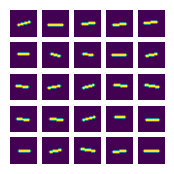

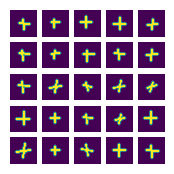

In [3]:
from scipy.ndimage import rotate


# Create plus/minus operand signs
def generate_images(number_of_images=50, sign='-'):
    blank_images = np.zeros([number_of_images, 28, 28])  # Dimensionality matches the size of MNIST images (28x28)
    x = np.random.randint(12, 16, (number_of_images, 2)) # Randomized x coordinates
    y1 = np.random.randint(6, 10, number_of_images)       # Randomized y coordinates
    y2 = np.random.randint(18, 22, number_of_images)     # -||-

    for i in range(number_of_images): # Generate n different images
        cv2.line(blank_images[i], (y1[i], x[i,0]), (y2[i], x[i, 1]), (255,0,0), 2, cv2.LINE_AA)     # Draw lines with randomized coordinates
        if sign == '+':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA) # Draw lines with randomized coordinates
        if sign == '*':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA)
            # Rotate 45 degrees
            blank_images[i] = rotate(blank_images[i], -50, reshape=False)
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA)
            blank_images[i] = rotate(blank_images[i], -50, reshape=False)
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA)

    return blank_images

def show_generated(images, n=5):
    plt.figure(figsize=(2, 2))
    for i in range(n**2):
        plt.subplot(n, n, i+1)
        plt.axis('off')
        plt.imshow(images[i])
    plt.show()

show_generated(generate_images())
show_generated(generate_images(sign='+'))

In [4]:
def create_data(highest_integer, num_addends=2, operands=['+', '-']):
    """
    Creates the following data for all pairs of integers up to [1:highest integer][+/-][1:highest_integer]:

    @return:
    X_text: '51+21' -> text query of an arithmetic operation (5)
    X_img : Stack of MNIST images corresponding to the query (5 x 28 x 28) -> sequence of 5 images of size 28x28
    y_text: '72' -> answer of the arithmetic text query
    y_img :  Stack of MNIST images corresponding to the answer (3 x 28 x 28)

    Images for digits are picked randomly from the whole MNIST dataset.
    """

    num_indices = [np.where(MNIST_labels==x) for x in range(10)]
    num_data = [MNIST_data[inds] for inds in num_indices]
    image_mapping = dict(zip(unique_characters[:10], num_data))
    image_mapping['-'] = generate_images()
    image_mapping['+'] = generate_images(sign='+')
    image_mapping['*'] = generate_images(sign='*')
    image_mapping[' '] = np.zeros([1, 28, 28])

    X_text, X_img, y_text, y_img = [], [], [], []

    for i in range(highest_integer + 1):      # First addend
        for j in range(highest_integer + 1):  # Second addend
            for sign in operands: # Create all possible combinations of operands
                query_string = to_padded_chars(str(i) + sign + str(j), max_len=max_query_length, pad_right=True)
                query_image = []
                for n, char in enumerate(query_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    query_image.append(image_set[index].squeeze())

                result = eval(query_string)
                result_string = to_padded_chars(result, max_len=max_answer_length, pad_right=True)
                result_image = []
                for n, char in enumerate(result_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    result_image.append(image_set[index].squeeze())

                X_text.append(query_string)
                X_img.append(np.stack(query_image))
                y_text.append(result_string)
                y_img.append(np.stack(result_image))

    return np.stack(X_text), np.stack(X_img)/255., np.stack(y_text), np.stack(y_img)/255.

def to_padded_chars(integer, max_len=3, pad_right=False):
    """
    Returns a string of len()=max_len, containing the integer padded with ' ' on either right or left side
    """
    length = len(str(integer))
    padding = (max_len - length) * ' '
    if pad_right:
        return str(integer) + padding
    else:
        return padding + str(integer)


# Creating our data

The dataset consists of 20000 samples that (additions and subtractions between all 2-digit integers) and they have two kinds of inputs and label modalities:

  **X_text**: strings containing queries of length 5: ['  1+1  ', '11-18', ...]

  **X_image**: a stack of images representing a single query, dimensions: [5, 28, 28]

  **y_text**: strings containing answers of length 3: ['  2', '156']

  **y_image**: a stack of images that represents the answer to a query, dimensions: [3, 28, 28]

(20000,) (20000, 5, 28, 28) (20000,) (20000, 3, 28, 28)
Query #6396

X_text: "31+98" = y_text: "129"


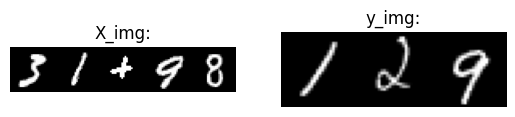

Query #846

X_text: "4+23 " = y_text: "27 "


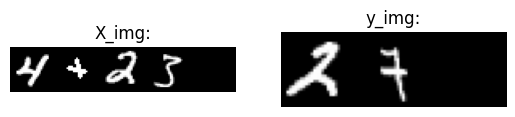

Query #2885

X_text: "14-42" = y_text: "-28"


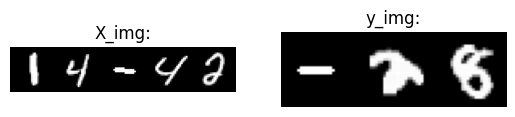

Query #1908

X_text: "9+54 " = y_text: "63 "


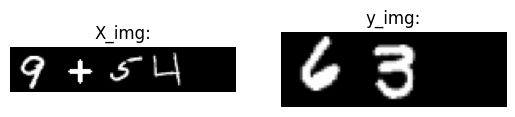

Query #1305

X_text: "6-52 " = y_text: "-46"


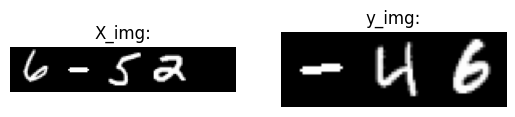

Query #6012

X_text: "30+6 " = y_text: "36 "


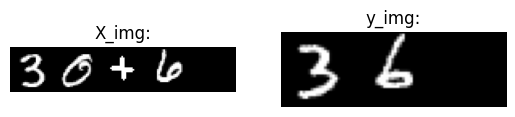

Query #7531

X_text: "37-65" = y_text: "-28"


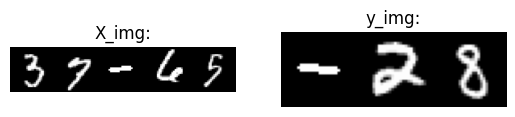

Query #9036

X_text: "45+18" = y_text: "63 "


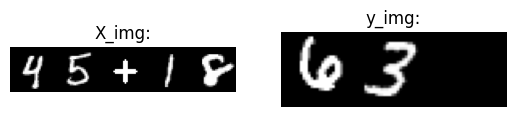

Query #4317

X_text: "21-58" = y_text: "-37"


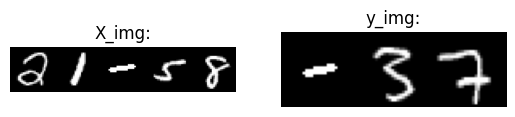

Query #226

X_text: "1+13 " = y_text: "14 "


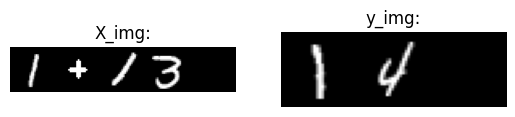

In [5]:
# Illustrate the generated query/answer pairs

unique_characters = '0123456789+- '       # All unique characters that are used in the queries (13 in total: digits 0-9, 2 operands [+, -], and a space character ' '.)
highest_integer = 99                      # Highest value of integers contained in the queries

max_int_length = len(str(highest_integer))# Maximum number of characters in an integer
max_query_length = max_int_length * 2 + 1 # Maximum length of the query string (consists of two integers and an operand [e.g. '22+10'])
max_answer_length = 3    # Maximum length of the answer string (the longest resulting query string is ' 1-99'='-98')

# Create the data (might take around a minute)
(MNIST_data, MNIST_labels), _ = tf.keras.datasets.mnist.load_data()
X_text, X_img, y_text, y_img = create_data(highest_integer)
print(X_text.shape, X_img.shape, y_text.shape, y_img.shape)


## Display the samples that were created
def display_sample(n):
    labels = ['X_img:', 'y_img:']
    for i, data in enumerate([X_img, y_img]):
        plt.subplot(1,2,i+1)
        # plt.set_figheight(15)
        plt.axis('off')
        plt.title(labels[i])
        plt.imshow(np.hstack(data[n]), cmap='gray')
    print('='*50, f'\nQuery #{n}\n\nX_text: "{X_text[n]}" = y_text: "{y_text[n]}"')
    plt.show()

for _ in range(10):
    display_sample(np.random.randint(0, 10000, 1)[0])

## Helper functions

The functions below will help with input/output of the data.

In [6]:
# One-hot encoding/decoding the text queries/answers so that they can be processed using RNNs
# You should use these functions to convert your strings and read out the output of your networks

def encode_labels(labels, max_len=3):
  n = len(labels)
  length = len(labels[0])
  char_map = dict(zip(unique_characters, range(len(unique_characters))))
  one_hot = np.zeros([n, length, len(unique_characters)])
  for i, label in enumerate(labels):
      m = np.zeros([length, len(unique_characters)])
      for j, char in enumerate(label):
          m[j, char_map[char]] = 1
      one_hot[i] = m

  return one_hot


def decode_labels(labels):
    pred = np.argmax(labels, axis=1)
    predicted = ''.join([unique_characters[i] for i in pred])

    return predicted

X_text_onehot = encode_labels(X_text)
y_text_onehot = encode_labels(y_text)

print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 5, 13) (20000, 3, 13)


In [7]:
import matplotlib.pyplot as plt

def plot_training_metrics(history, model_name):
    """
    Plots multiple training metrics: 
    - Accuracy vs Validation Accuracy
    - Epoch vs Training Accuracy
    - Loss vs Validation Loss
    - Loss vs Accuracy
    
    Parameters:
        history: The training history object returned by `fit()`.
        model_name: A string name of the model for labeling the plots.
    """
    # Extract metrics from the history object
    accuracy = history.history.get('accuracy', [])
    val_accuracy = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs = range(1, len(accuracy) + 1)

    # Plot 1: Accuracy vs Validation Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_accuracy, 'r--', label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy vs Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot 2: Epoch vs Training Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
    plt.title(f'{model_name} - Epoch vs Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot 3: Loss vs Validation Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
    plt.title(f'{model_name} - Loss vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot 4: Loss vs Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(loss, accuracy, 'g-', label='Loss vs Accuracy')
    plt.title(f'{model_name} - Loss vs Accuracy')
    plt.xlabel('Loss')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()


---
---

## I. Text-to-text RNN model

The following code showcases how Recurrent Neural Networks (RNNs) are built using Keras. Several new layers are going to be used:

1. LSTM
2. TimeDistributed
3. RepeatVector

The code cell below explains each of these new components.

<img src="https://i.ibb.co/NY7FFTc/Screenshot-2023-11-10-at-09-27-25.png" alt="Screenshot-2023-11-10-at-09-27-25" border="0" width="500"></a>


In [8]:
#!pip install keras-tuner

In [9]:
import tensorflow as tf
import keras_tuner as kt
import numpy as np
from tensorflow.keras.layers import LSTM, RepeatVector, Dense, TimeDistributed
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# X_text_onehot and y_text_onehot are assumed to be pre-processed
# unique_characters and max_answer_length should also be defined

# Step 1: Prepare the Data
X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text_onehot, y_text_onehot, test_size=0.3, random_state=42)

# Step 2: Define Hypermodel with Tuning
def build_text2text_model_with_tuning(hp):
    text2text = tf.keras.Sequential()

    # Tune the number of LSTM units
    lstm_units = hp.Int('lstm_units', min_value=128, max_value=512, step=64)

    # Add the first LSTM layer
    text2text.add(LSTM(lstm_units, input_shape=(None, len(unique_characters))))

    # Add RepeatVector layer
    text2text.add(RepeatVector(max_answer_length))

    # Add the second LSTM layer
    text2text.add(LSTM(lstm_units, return_sequences=True))

    # Add TimeDistributed Dense layer
    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Compile the model with tunable learning rate
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='log')
    text2text.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )

    return text2text

# Initialize RandomSearch Tuner
tuner = kt.RandomSearch(
    build_text2text_model_with_tuning,
    objective='val_accuracy',  # Target metric
    max_trials=10,             # Limit the total number of trials to 50
    directory='tuning_results',
    project_name='text2text_tuning'
)

# Search for the best hyperparameters with 30 trials
tuner.search(X_text_train, y_text_train, epochs=30, validation_data=(X_text_test, y_text_test))

# Get the best model after the search
best_model = tuner.get_best_models(num_models=1)[0]

# Step 4: Retrain the best model to capture training history
history = best_model.fit(
    X_text_train,
    y_text_train,
    epochs=30,
    validation_data=(X_text_test, y_text_test),
    batch_size=64
)

# Evaluate the best model
results = best_model.evaluate(X_text_test, y_text_test, verbose=1)
print(f"Test Loss: {results[0]}, Test Accuracy: {results[1]}")

# Predict and Decode Outputs
def decode_predictions(predictions, max_len):
    decoded = []
    for pred in predictions:
        decoded.append(decode_labels(pred[:max_len]))
    return decoded

# Decode Predictions and compare with the expected results
predictions = best_model.predict(X_text_test)
decoded_preds = decode_predictions(predictions, max_answer_length)

for i in range(5):
    print(f"Input: {''.join([unique_characters[np.argmax(x)] for x in X_text_test[i]])}")
    print(f"Expected: {''.join([unique_characters[np.argmax(y)] for y in y_text_test[i]])}")
    print(f"Predicted: {decoded_preds[i]}")
    print("=" * 20)

tuner.results_summary()

Trial 10 Complete [00h 04m 33s]
val_accuracy: 0.5516111254692078

Best val_accuracy So Far: 0.9980000257492065
Total elapsed time: 00h 43m 47s
Epoch 1/30
219/219 [==============================] - 8s 24ms/step - loss: 0.0018 - accuracy: 0.9998 - val_loss: 0.0042 - val_accuracy: 0.9988
Epoch 2/30
219/219 [==============================] - 4s 20ms/step - loss: 7.6683e-04 - accuracy: 1.0000 - val_loss: 0.0038 - val_accuracy: 0.9989
Epoch 3/30
219/219 [==============================] - 4s 20ms/step - loss: 6.0222e-04 - accuracy: 1.0000 - val_loss: 0.0036 - val_accuracy: 0.9990
Epoch 4/30
219/219 [==============================] - 4s 20ms/step - loss: 5.0136e-04 - accuracy: 1.0000 - val_loss: 0.0035 - val_accuracy: 0.9990
Epoch 5/30
219/219 [==============================] - 4s 20ms/step - loss: 4.2566e-04 - accuracy: 1.0000 - val_loss: 0.0033 - val_accuracy: 0.9991
Epoch 6/30
219/219 [==============================] - 4s 21ms/step - loss: 3.6725e-04 - accuracy: 1.0000 - val_loss: 0.0033 - 

188/188 [==============================] - 1s 5ms/step
Test Accuracy: 99.91%


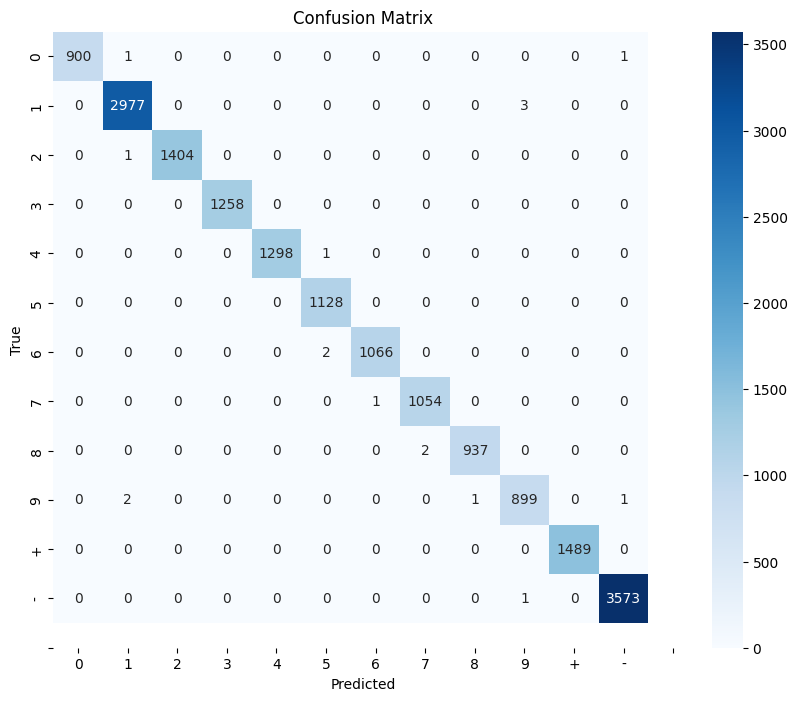

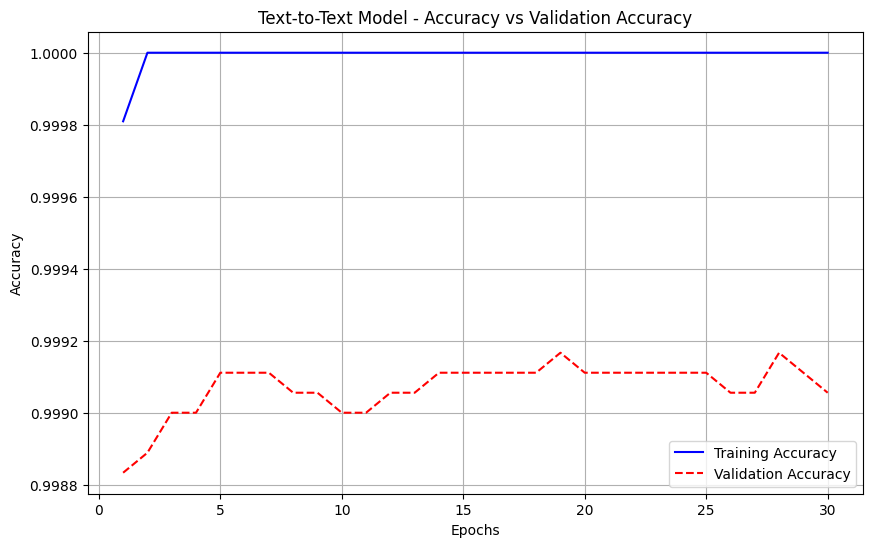

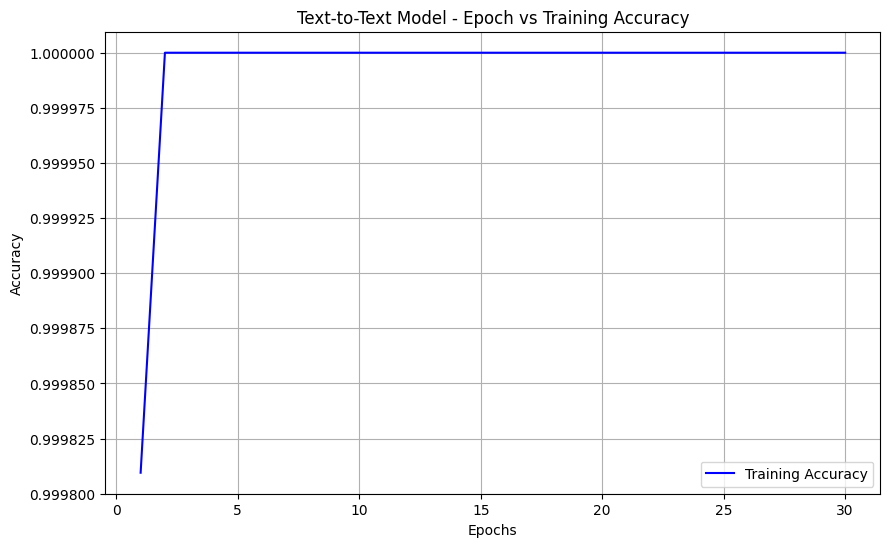

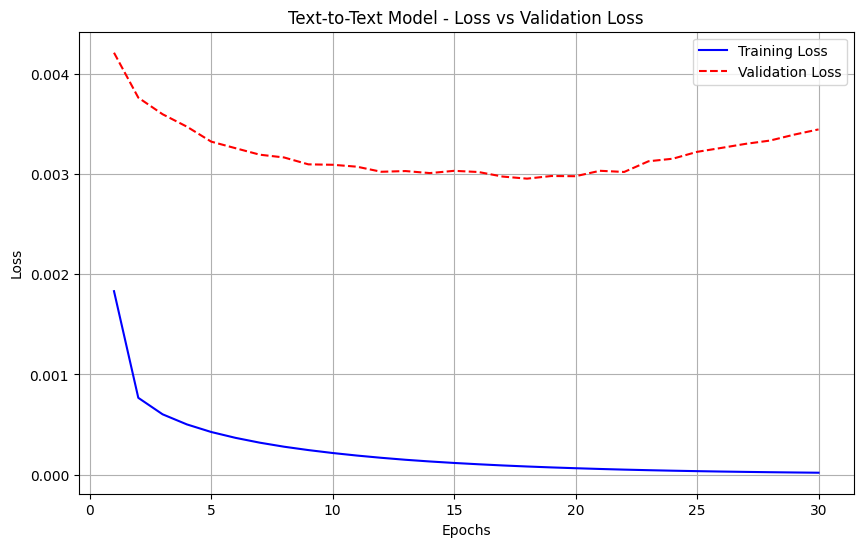

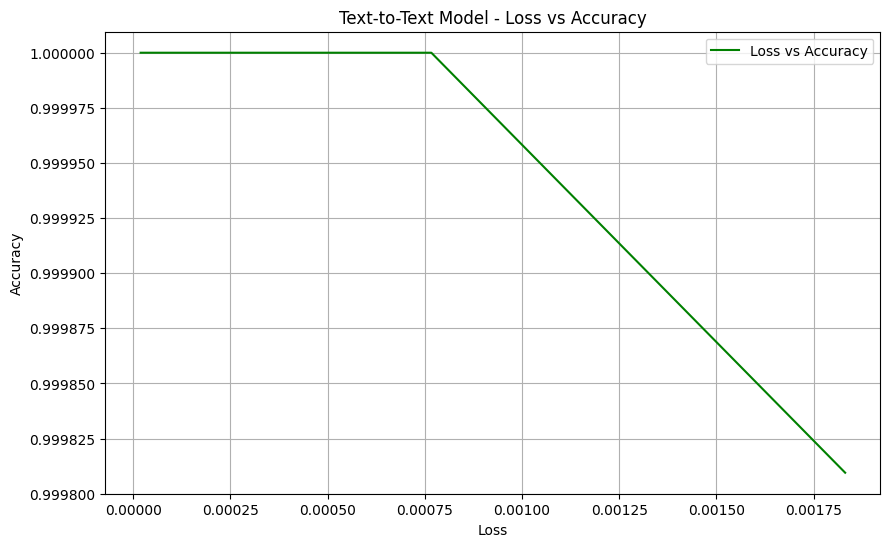

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# Step 1: Get Predictions from Best Model
predictions = best_model.predict(X_text_test)
predicted_classes = np.argmax(predictions, axis=-1)  # Convert predictions to class indices

# Step 2: Calculate Accuracy
y_true_classes = np.argmax(y_text_test, axis=-1)  # True classes

# Calculate accuracy score
accuracy = accuracy_score(y_true_classes.flatten(), predicted_classes.flatten())
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 3: Confusion Matrix
cm = confusion_matrix(y_true_classes.flatten(), predicted_classes.flatten())

# Step 4: Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_characters, yticklabels=unique_characters)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

plot_training_metrics(history, "Text-to-Text Model")


---
---

## II. Image to text RNN Model

Hint: There are two ways of building the encoder for such a model - again by using the regular LSTM cells (with flattened images as input vectors) or recurrect convolutional layers [ConvLSTM2D](https://keras.io/api/layers/recurrent_layers/conv_lstm2d/).

The goal here is to use **X_img** as inputs and **y_text** as outputs.

Trial 10 Complete [00h 03m 12s]
val_accuracy: 0.4724999964237213

Best val_accuracy So Far: 0.7333333492279053
Total elapsed time: 00h 31m 21s


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDist  (None, 5, 28, 28, 32)     320       
 ributed)                                                        
                                                                 
 time_distributed_1 (TimeDi  (None, 5, 14, 14, 32)     0         
 stributed)                                                      
                                                                 
 time_distributed_2 (TimeDi  (None, 5, 14, 14, 256)    73984     
 stributed)                                                      
                                                                 
 time_distributed_3 (TimeDi  (None, 5, 7, 7, 256)      0         
 stributed)                                                      
                                                                 
 time_distributed_4 (TimeDi  (None, 5, 12544)          0

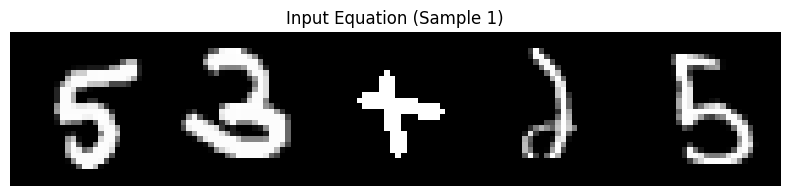

Predicted Answer: '76', True Answer: '78'
--------------------------------------------------


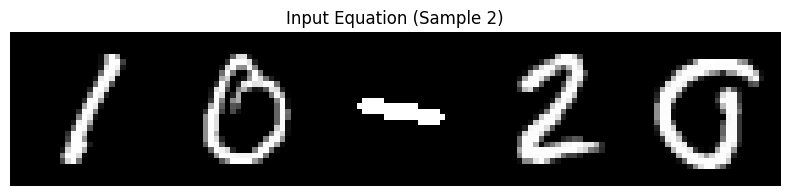

Predicted Answer: '-8', True Answer: '-10'
--------------------------------------------------


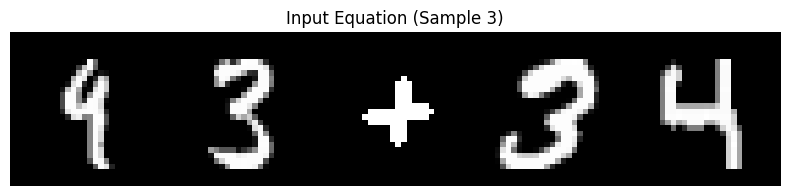

Predicted Answer: '87', True Answer: '77'
--------------------------------------------------


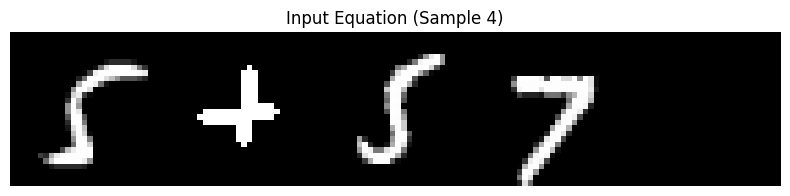

Predicted Answer: '63', True Answer: '62'
--------------------------------------------------


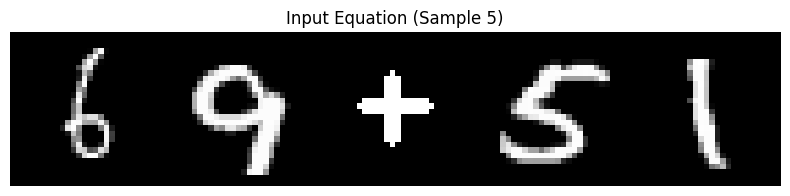

Predicted Answer: '120', True Answer: '120'
--------------------------------------------------
Results summary
Results in tuning_results/image2text_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 00 summary
Hyperparameters:
conv1_filters: 32
conv2_filters: 256
lstm_units: 256
lstm_units_2: 256
learning_rate: 0.005747972480809448
Score: 0.7333333492279053

Trial 02 summary
Hyperparameters:
conv1_filters: 64
conv2_filters: 192
lstm_units: 384
lstm_units_2: 256
learning_rate: 0.00032745183272016364
Score: 0.5981666445732117

Trial 05 summary
Hyperparameters:
conv1_filters: 128
conv2_filters: 256
lstm_units: 384
lstm_units_2: 128
learning_rate: 0.0004419772860765411
Score: 0.5401666760444641

Trial 09 summary
Hyperparameters:
conv1_filters: 96
conv2_filters: 192
lstm_units: 256
lstm_units_2: 384
learning_rate: 7.863692634972234e-05
Score: 0.4724999964237213

Trial 08 summary
Hyperparameters:
conv1_filters: 128
conv2_filters: 64
lstm_units: 256
lstm_unit

In [11]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, TimeDistributed, LSTM, RepeatVector, Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Define the model with hyperparameters to tune
def build_image2text_model_with_tuning(hp):
    model = Sequential()

    # Define the input shape
    input_shape = (X_img.shape[1], X_img.shape[2], X_img.shape[3], 1)

    # Add TimeDistributed Conv2D layers with tunable filters and kernel size
    model.add(TimeDistributed(Conv2D(
        hp.Int('conv1_filters', min_value=32, max_value=128, step=32),
        (3, 3), activation='relu', padding='same'), input_shape=input_shape))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))

    model.add(TimeDistributed(Conv2D(
        hp.Int('conv2_filters', min_value=64, max_value=256, step=64),
        (3, 3), activation='relu', padding='same')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))

    # Flatten the feature maps
    model.add(TimeDistributed(Flatten()))

    # Add an LSTM layer with tunable number of units
    model.add(LSTM(hp.Int('lstm_units', min_value=128, max_value=512, step=128)))

    # Repeat the context vector to match the output sequence length
    model.add(RepeatVector(max_answer_length))

    # Add an LSTM decoder with return_sequences=True
    model.add(LSTM(hp.Int('lstm_units_2', min_value=128, max_value=512, step=128), return_sequences=True))

    # TimeDistributed Dense layer to get predictions at each time step
    model.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Compile the model with tunable learning rate
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='log')
    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy'])

    model.summary()
    return model

# Prepare the data
X_img_expanded = np.expand_dims(X_img, axis=-1)  # Shape: (20000, 5, 28, 28, 1)
X_train, X_val, y_train, y_val = train_test_split(X_img_expanded, y_text_onehot, test_size=0.1, random_state=42)

# Initialize the RandomSearch tuner
tuner = kt.RandomSearch(
    build_image2text_model_with_tuning,
    objective='val_accuracy',
    max_trials=10,
    directory='tuning_results',
    project_name='image2text_tuning'
)

# Start the search for the best hyperparameters
tuner.search(X_train, y_train, epochs=30, batch_size=128, validation_data=(X_val, y_val))

# Get the best model after the search
best_model = tuner.get_best_models(num_models=1)[0]

history = best_model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=128,
    validation_data=(X_val, y_val)
)
# Evaluate the best model
val_loss, val_accuracy = best_model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

# Predict and Decode function
def decode_labels_batch(labels_batch):
    predictions = []
    for labels in labels_batch:
        pred = np.argmax(labels, axis=1)
        predicted = ''.join([unique_characters[i] for i in pred])
        predictions.append(predicted.strip())
    return predictions

def predict_and_decode(model, X_input, y_true):
    y_pred = model.predict(X_input)
    predicted_texts = decode_labels_batch(y_pred)
    true_texts = decode_labels_batch(y_true)
    for i in range(len(X_input)):
        # Get the input image sequence for the current sample
        input_images = X_input[i]  # Shape: (sequence_length, 28, 28, 1)

        # Remove the channel dimension and convert to 2D images
        input_images_2d = input_images.squeeze(-1)  # Shape: (sequence_length, 28, 28)

        # Concatenate images horizontally to form the equation
        concatenated_image = np.hstack(input_images_2d)

        # Plot the concatenated image
        plt.figure(figsize=(10, 2))
        plt.imshow(concatenated_image, cmap='gray')
        plt.axis('off')
        plt.title(f"Input Equation (Sample {i+1})")
        plt.show()

        # Print the predicted and true outputs
        print(f"Predicted Answer: '{predicted_texts[i]}', True Answer: '{true_texts[i]}'")
        print('-' * 50)

# Display Predictions for a few test samples
num_samples = 5
X_input = X_val[:num_samples]
y_input = y_val[:num_samples]
predict_and_decode(best_model, X_input, y_input)

# Display Hyperparameter Search Results
tuner.results_summary()

 1/63 [..............................] - ETA: 1s

63/63 [==============================] - 0s 7ms/step


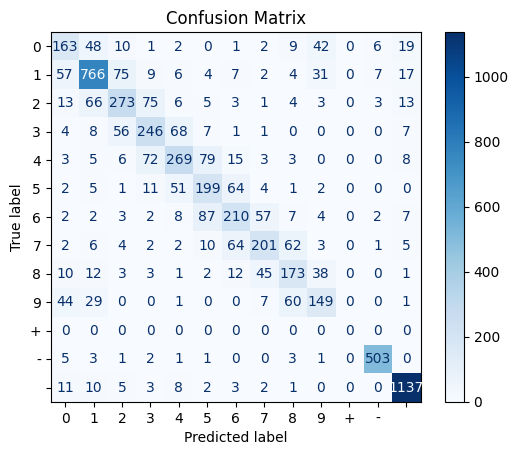

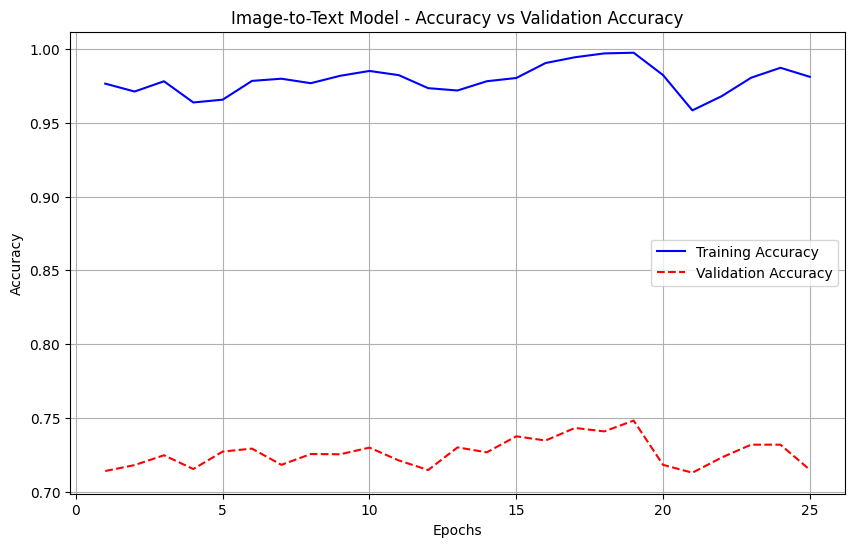

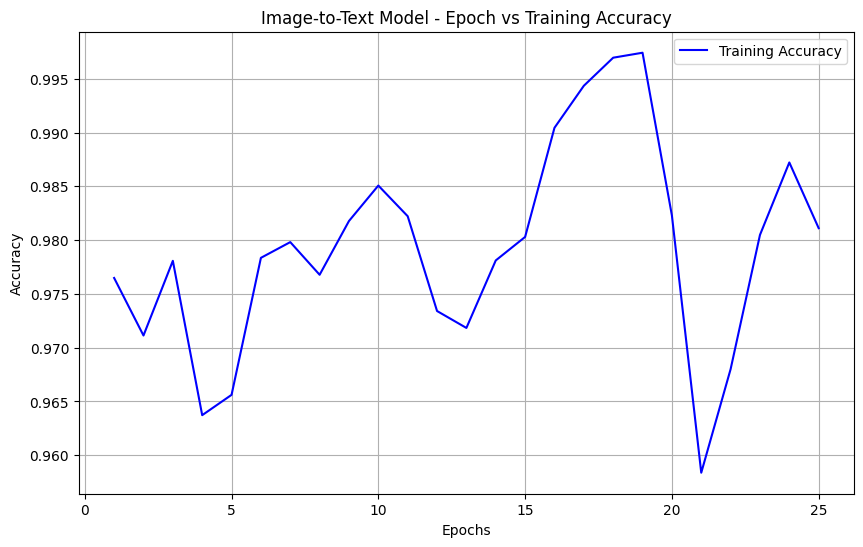

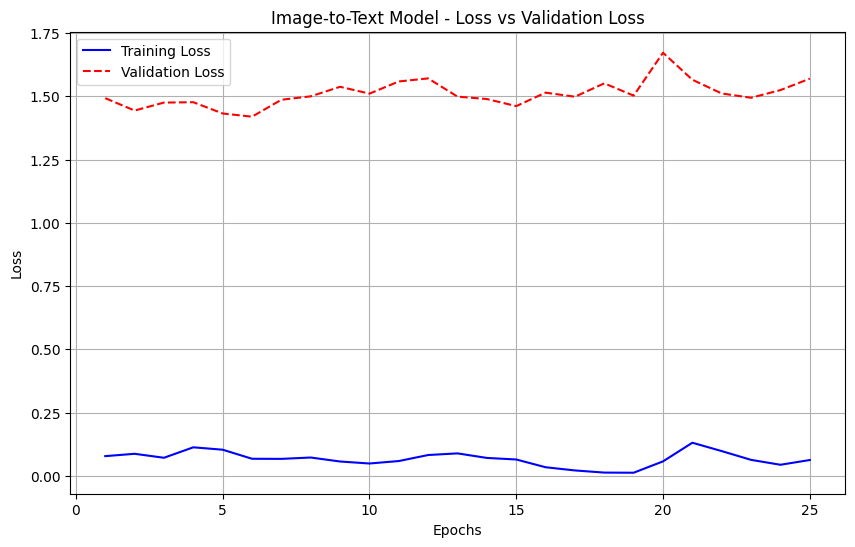

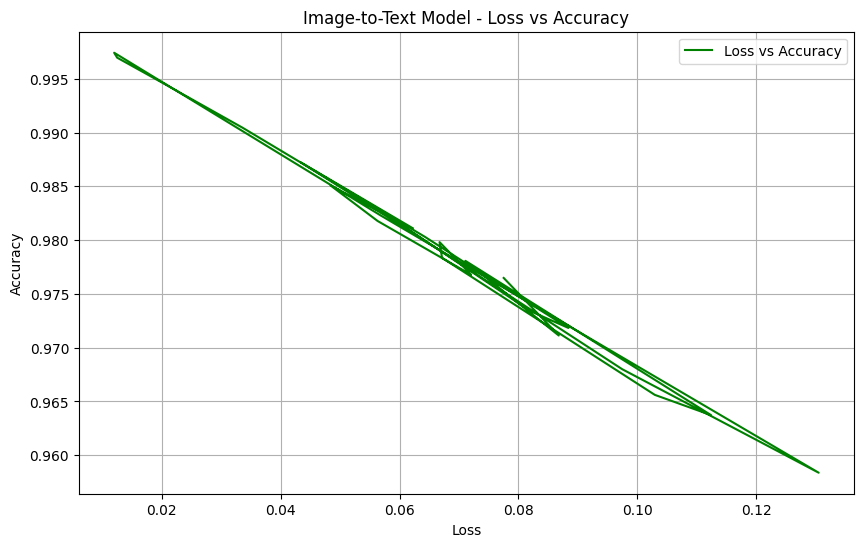

In [12]:
import numpy as np
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow.keras.utils import to_categorical

# Function to decode the model's predictions into text
# Preserving the whitespaces in predicted text for correct sequence length
def decode_labels_batch(labels_batch):
    predictions = []
    for labels in labels_batch:
        pred = np.argmax(labels, axis=1)  # Get the predicted class indices
        predicted = ''.join([unique_characters[i] for i in pred])  # Convert indices to text without stripping spaces
        predictions.append(predicted)
    return predictions

# Function to convert one-hot encoded labels back to integer indices
def onehot_to_labels(onehot_labels):
    return np.argmax(onehot_labels, axis=-1)  # Convert one-hot labels to indices

# Generate predictions for the validation set
y_pred = best_model.predict(X_val)  # Model predictions (shape: [num_samples, sequence_length, num_classes])

# Decode the predictions and true labels
y_pred_decoded = decode_labels_batch(y_pred)  # Decode predicted sequences
y_true_decoded = decode_labels_batch(y_val)  # Decode true sequences

# Flatten the predictions and true labels for the confusion matrix
y_pred_flat = [list(pred) for pred in y_pred_decoded]
y_true_flat = [list(true) for true in y_true_decoded]

# Flatten to compare each character prediction
y_pred_flat = [char for seq in y_pred_flat for char in seq]
y_true_flat = [char for seq in y_true_flat for char in seq]

# Create the confusion matrix using sklearn's confusion_matrix function
unique_characters_list = list(unique_characters)
conf_matrix = metrics.confusion_matrix(y_true_flat, y_pred_flat, labels=unique_characters_list)


# Display the confusion matrix using a heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=unique_characters)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

plot_training_metrics(history, "Image-to-Text Model")

---
---

## III. Text to image RNN Model

Hint: to make this model work really well you could use deconvolutional layers in your decoder (you might need to look up ***Conv2DTranspose*** layer). However, regular vector-based decoder will work as well.

The goal here is to use **X_text** as inputs and **y_img** as outputs.

Trial 10 Complete [00h 05m 39s]
val_loss: 0.05060800909996033

Best val_loss So Far: 0.039040714502334595
Total elapsed time: 00h 57m 31s
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5, 13)]           0         
                                                                 
 lstm (LSTM)                 (None, 128)               72704     
                                                                 
 repeat_vector (RepeatVecto  (None, 3, 128)            0         
 r)                                                              
                                                                 
 lstm_1 (LSTM)               (None, 3, 128)            131584    
                                                                 
 time_distributed (TimeDist  (None, 3, 784)            101136    
 ributed)                                              

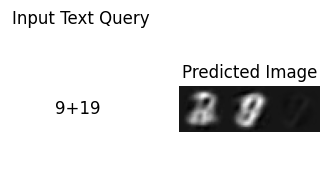

  GT   

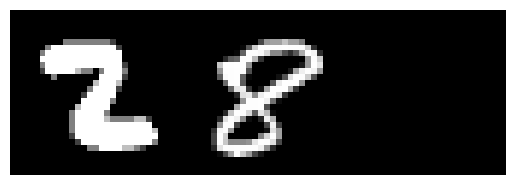

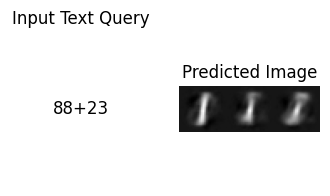

  GT   

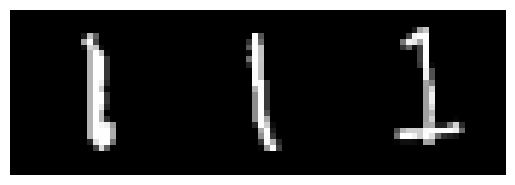

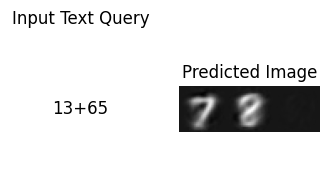

  GT   

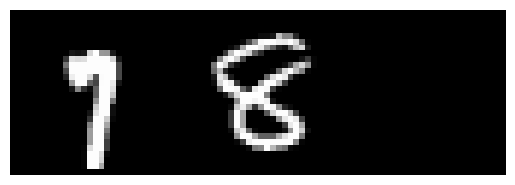

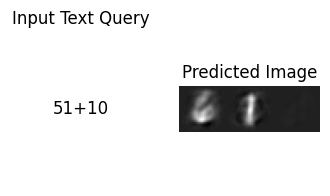

  GT   

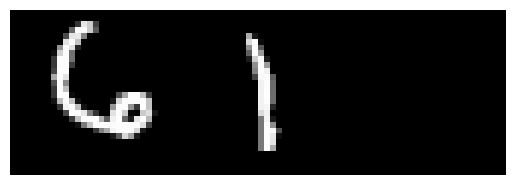

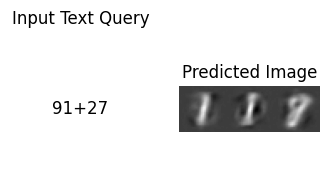

  GT   

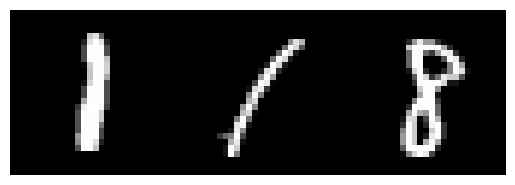

In [13]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.layers import LSTM, RepeatVector, Dense, TimeDistributed, Reshape
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Define the model with hyperparameters to tune
def build_text2image_model_with_tuning(hp):
    encoder_input_shape = (max_query_length, len(unique_characters))  # Shape of the text input
    decoder_output_shape = (max_answer_length, 28, 28, 1)  # Shape of the image output

    # Encoder
    encoder_inputs = tf.keras.Input(shape=encoder_input_shape)

    # Tune the number of units in the LSTM encoder
    lstm_units_encoder = hp.Int('encoder_lstm_units', min_value=128, max_value=512, step=128)
    encoder_lstm = LSTM(lstm_units_encoder)(encoder_inputs)

    # Repeat vector to prepare for decoder input
    encoder_repeat = RepeatVector(max_answer_length)(encoder_lstm)

    # Decoder
    lstm_units_decoder = hp.Int('decoder_lstm_units', min_value=128, max_value=512, step=128)
    decoder_lstm = LSTM(lstm_units_decoder, return_sequences=True)(encoder_repeat)

    # TimeDistributed Dense layer to predict the image pixels
    decoder_dense = TimeDistributed(Dense(28 * 28))(decoder_lstm)
    decoder_reshape = Reshape(decoder_output_shape)(decoder_dense)

    # Create the model
    text2image = tf.keras.Model(inputs=encoder_inputs, outputs=decoder_reshape)

    # Compile the model with tunable learning rate
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='log')
    text2image.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['mae'])

    text2image.summary()
    return text2image

# Hyperparameter tuning with RandomSearch
tuner = kt.RandomSearch(
    build_text2image_model_with_tuning,
    objective='val_loss',
    max_trials=10,
    directory='tuning_results',
    project_name='text2image_tuning'
)

# Prepare the data
X_train_text, X_test_text, y_train_img, y_test_img = train_test_split(X_text, y_img, test_size=0.2, random_state=42)

# Encode text data
X_train_text_encoded = encode_labels(X_train_text)
X_test_text_encoded = encode_labels(X_test_text)

# Start the search for the best hyperparameters
tuner.search(X_train_text_encoded, y_train_img, epochs=50, batch_size=32, validation_data=(X_test_text_encoded, y_test_img))

# Get the best model after the search
best_model = tuner.get_best_models(num_models=1)[0]

history = best_model.fit(
    X_train_text_encoded,
    y_train_img,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_text_encoded, y_test_img)
)

# Evaluate the best model
val_loss, val_mae = best_model.evaluate(X_test_text_encoded, y_test_img)
print(f"Validation Loss: {val_loss:.4f}, Validation MAE: {val_mae:.4f}")

# Test the best model with some samples
def test_text2image_model(model, X_text, y_img, num_samples=5):
    indices = np.random.choice(len(X_text), num_samples, replace=False)
    X_test = X_text[indices]
    y_test = y_img[indices]

    X_test_encoded = encode_labels(X_test)
    predictions = model.predict(X_test_encoded)

    for i in range(num_samples):
        plt.figure(figsize=(4, 2))

        plt.subplot(1, 2, 1)
        plt.axis('off')
        plt.title('Input Text Query')
        plt.text(0.5, 0.5, X_test[i], ha='center', va='center', fontsize=12)

        plt.subplot(1, 2, 2)
        plt.axis('off')
        plt.title('Predicted Image')
        plt.imshow(np.hstack(predictions[i]), cmap='gray')

        plt.show()
        print("="*30)
        print(f"  GT  ", end =" ")
        plt.imshow(np.hstack(y_test[i]), cmap='gray')
        plt.axis('off')
        plt.show()

# Test the best model
test_text2image_model(best_model, X_test_text, y_test_img)


In [16]:
def plot_training_metrics1(history, model_name):
    """
    Plots training metrics: 
    - Loss vs Validation Loss
    - MAE vs Validation MAE
    
    Parameters:
        history: The training history object returned by `fit()`.
        model_name: A string name of the model for labeling the plots.
    """
    loss = history.history['loss']  # Training loss
    val_loss = history.history['val_loss']  # Validation loss
    mae = history.history['mae']  # Training mean absolute error
    val_mae = history.history['val_mae']  # Validation mean absolute error
    epochs = range(1, len(loss) + 1)

    # Plot 1: Loss vs Validation Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
    plt.title(f'{model_name} - Loss vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot 2: MAE vs Validation MAE
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, mae, 'g-', label='Training MAE')
    plt.plot(epochs, val_mae, 'm--', label='Validation MAE')
    plt.title(f'{model_name} - MAE vs Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.legend()
    plt.grid()
    plt.show()


1/1 [==============================] - 0s 33ms/step
Confusion Matrix for Sample 1:


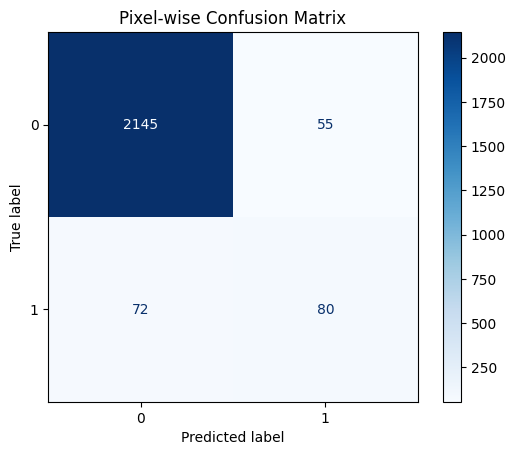

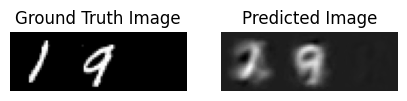

Confusion Matrix for Sample 2:


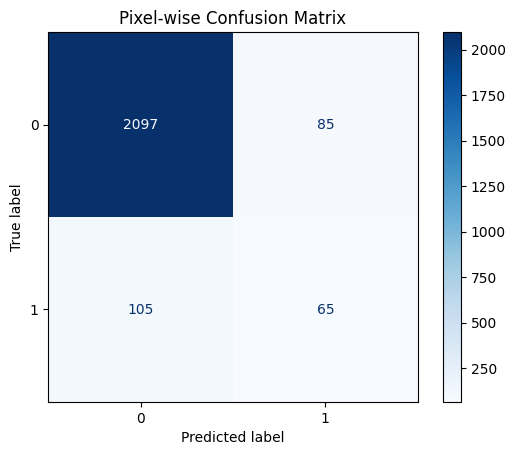

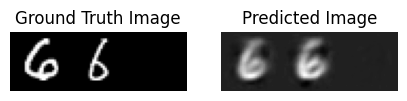

Confusion Matrix for Sample 3:


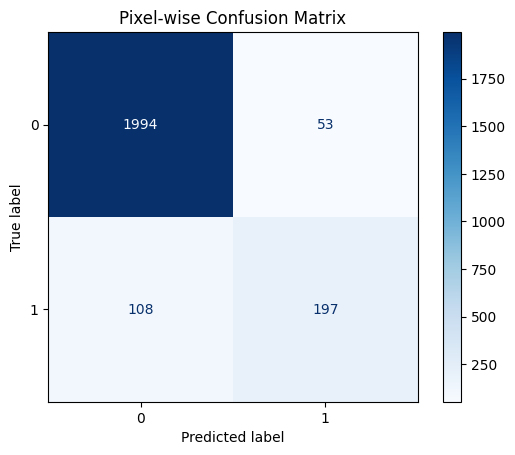

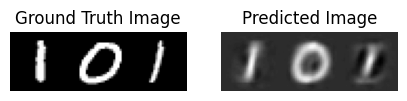

Confusion Matrix for Sample 4:


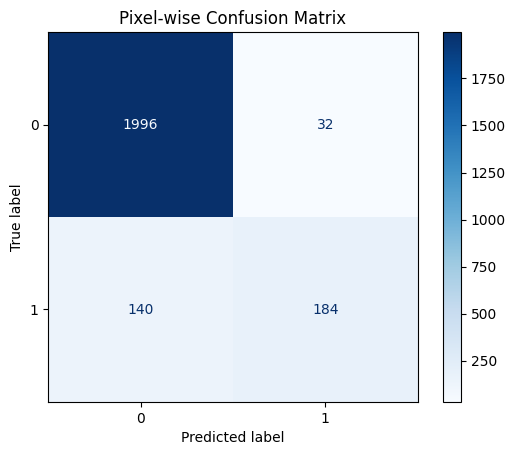

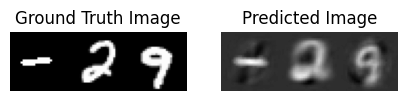

Confusion Matrix for Sample 5:


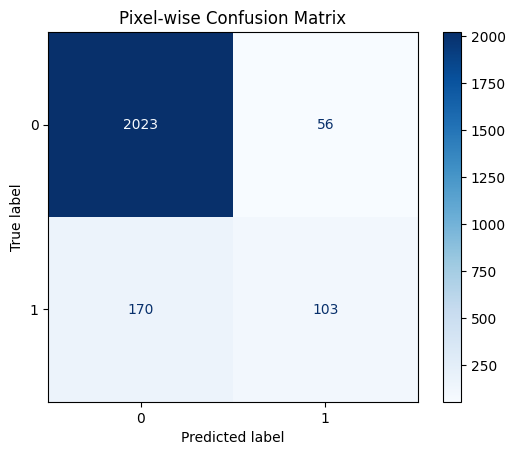

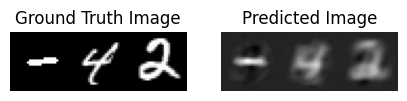

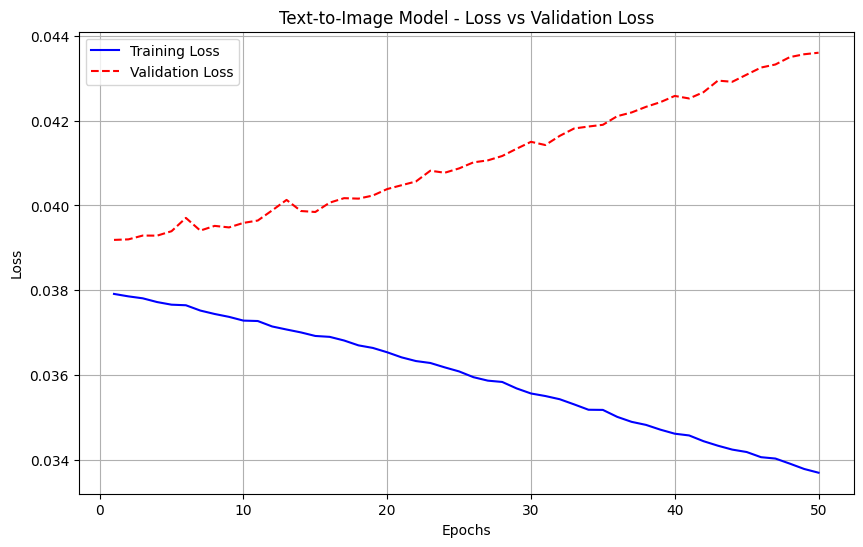

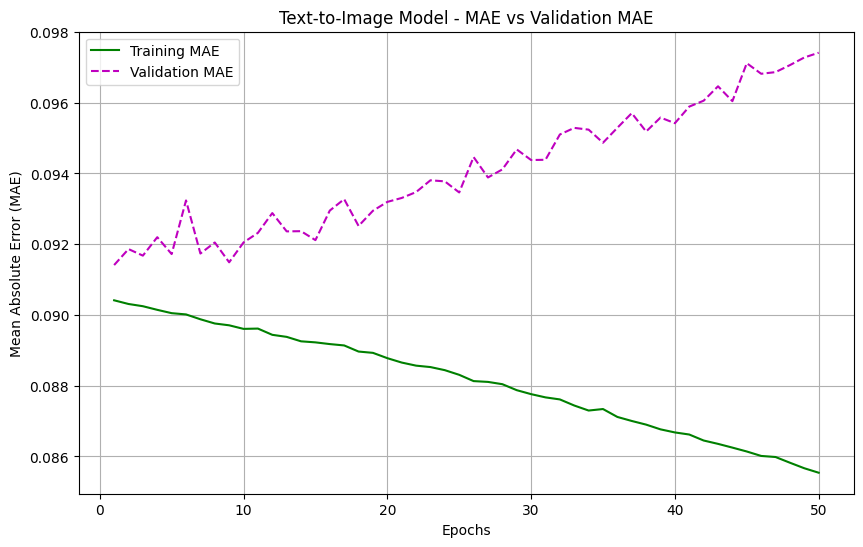

In [17]:
import numpy as np
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow.keras.utils import to_categorical

# Function to convert images to binary format for confusion matrix
def binarize_images(images):
    """
    Convert images to binary (0 or 1) for pixel-wise comparison.
    """
    return (images > 0.5).astype(int)  # Binarize by a threshold of 0.5

# Function to compute pixel-wise confusion matrix
def compute_pixel_confusion_matrix(y_true, y_pred):
    """
    Compute pixel-wise confusion matrix for true and predicted images.
    Flatten images and compute confusion matrix.
    """
    # Flatten images from shape (max_answer_length, 28, 28, 1) to 2D arrays
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    # Binarize both true and predicted images (values are 0 or 1)
    y_true_bin = binarize_images(y_true_flat)
    y_pred_bin = binarize_images(y_pred_flat)

    # Compute confusion matrix
    conf_matrix = metrics.confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])

    return conf_matrix

# Function to display confusion matrix
def plot_confusion_matrix(conf_matrix):
    """
    Plot the confusion matrix using matplotlib.
    """
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['0', '1'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Pixel-wise Confusion Matrix")
    plt.show()

def test_and_compute_confusion_matrix(model, X_text, y_img, num_samples=5):
    indices = np.random.choice(len(X_text), num_samples, replace=False)
    X_test = X_text[indices]
    y_test = y_img[indices]

    X_test_encoded = encode_labels(X_test)
    y_pred = model.predict(X_test_encoded)

    # Compute the confusion matrix for each image in the batch
    for i in range(num_samples):
        y_true = y_test[i]  # True image
        y_pred_image = y_pred[i]  # Predicted image

        # Compute confusion matrix for this image
        conf_matrix = compute_pixel_confusion_matrix(y_true, y_pred_image)

        # Plot confusion matrix for this image
        print(f"Confusion Matrix for Sample {i + 1}:")
        plot_confusion_matrix(conf_matrix)

        # Optionally: Visualize the input and predicted images
        plt.figure(figsize=(5, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(np.hstack(y_true), cmap='gray')
        plt.axis('off')
        plt.title("Ground Truth Image")

        plt.subplot(1, 2, 2)
        plt.imshow(np.hstack(y_pred_image), cmap='gray')
        plt.axis('off')
        plt.title("Predicted Image")

        plt.show()


test_and_compute_confusion_matrix(best_model, X_test_text, y_test_img)
plot_training_metrics1(history, "Text-to-Image Model")